In [5]:
import pypsa
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pypsa.plot.maps.static import add_legend_circles, add_legend_patches

# System-Level Results - CI Procurement Allocation
This notebook includes scripts to evaluate:
1) System-level and CI procurement results
2) CI procurement allocation

## 1 - System-level and CI procurement results
- CI load
- Total system cost
- System CO2 emissions
- Generation and capacity statistics (both at system and CI level)

In [6]:
# 0 - Helpers
def get_network_path(scenario, path = False):
    """
    Retrieve the network file path for a given scenario.
    
    - path = False means the default model repo path is used --> go back one level and go to "results/{scenario}/networks/network.nc"
    - path = "custom-path" means the networks are saved in a custom path where the network name is the same as the scenario name --> "custom-path/{scenario}.nc"
    """

    if not path: # Default model repo path: go back one level and go to results/...
        # Define the scenario directory
        scenario_dir = os.path.join("..", f"results/{scenario}/networks")
        if not os.path.exists(scenario_dir):
            print(f"Scenario directory {scenario_dir} not found, skipping.")
            return None
        
        # Get scenario network file
        nc_files = [f for f in os.listdir(scenario_dir) if f.endswith(".nc")]
        if not nc_files:
            print(f"Scenario network file not found in {scenario_dir}, skipping.")
            return None
        
        network_path = os.path.join(scenario_dir, nc_files[0])
        
    else: # If a custom path is provided, where the network name is the same as the scenario name
        # Define the scenario directory
        scenario_dir = path

        # Get scenario network file
        network_path = f"{scenario_dir}/{scenario}.nc"
        if not os.path.exists(network_path):
            print(f"{scenario} network file not found in {scenario_dir}, skipping.")
            return None

    return network_path

solar_carrier = ["solar","solar-hsat","solar rooftop"]
wind_carrier = ["onwind","offwind-ac","offwind-dc","offwind-float"]
carrier_list = solar_carrier + wind_carrier

def get_res_cap(network, only_ci = True):
    """Get the installed capacity of solar and wind generators."""

    n = network.copy()
        
    # Copy time-dependent data
    if only_ci:
        gen = n.generators[n.generators.ci != ""].copy() if "ci" in n.generators.columns else n.generators.loc[[],:]
        link = n.links[n.links.ci != ""].copy() if "ci" in n.links.columns else n.links.loc[[],:]
    else:
        gen = n.generators.copy()
        link = n.links.copy()
    
    solar_cap = round(gen[gen.carrier.isin(solar_carrier)].p_nom_opt.sum() / 1e3) # MW to GW
    wind_cap = round(gen[gen.carrier.isin(wind_carrier)].p_nom_opt.sum() / 1e3) # MW to GW
    
    return [solar_cap, wind_cap]

def get_res_gen(network, only_ci = True):
    """Get the generation of solar and wind generators."""

    n = network.copy()
    weights = n.snapshot_weightings["generators"]
    
    gen = n.generators_t.p.copy()
    link = n.links_t.p1.copy()
        
    # Copy time-dependent data
    if only_ci:
        gen_i = n.generators[n.generators.ci != ""].index if "ci" in n.generators else []
        gen = gen[gen_i]

        link_i = n.links[n.links.ci != ""].index if "ci" in n.links else []
        link = link[link_i]
    
    df_gen = pd.DataFrame(weights @ gen / 1e6) # MWh to TWh
    df_gen["carrier"] = df_gen.index.map(n.generators.carrier)

    df_link = pd.DataFrame(weights @ link / 1e6) # MWh to TWh
    df_link["carrier"] = df_link.index.map(n.links.carrier)

    solar_gen = round(df_gen[df_gen.carrier.isin(solar_carrier)].generators.sum())
    wind_gen = round(df_gen[df_gen.carrier.isin(wind_carrier)].generators.sum())

    return [solar_gen, wind_gen]

def get_solar_wind_curtailment(network):
    """Get the curtailment of solar and wind generators as a percentage."""

    n = network.copy()
    df_curt = n.statistics.curtailment(nice_names=False)
    df_gen = n.statistics.energy_balance(nice_names=False)

    df_curt = df_curt[df_curt.index.get_level_values("component") == "Generator"].groupby("carrier").sum()
    df_gen = df_gen[df_gen.index.get_level_values("component") == "Generator"].groupby("carrier").sum()

    solar_curt = df_curt.T[df_curt.index.isin(solar_carrier)].sum()
    wind_curt = df_curt.T[df_curt.index.isin(wind_carrier)].sum()

    solar_gen = df_gen.T[df_gen.index.isin(solar_carrier)].sum()
    wind_gen = df_gen.T[df_gen.index.isin(wind_carrier)].sum()

    solar_c = round((solar_curt/(solar_curt + solar_gen)) * 100)
    wind_c = round((wind_curt/(wind_curt + wind_gen)) * 100)

    return [solar_c, wind_c]

def compile_CI_statistics(network, df_cap_carrier_country=False, df_gen_carrier_country=False):
    """Compile the capacity, generation, and curtailment statistics for solar and wind generators."""

    df = pd.DataFrame({"Capacity CI (GW)":get_res_cap(network, only_ci = True),
                       "Capacity (GW)":get_res_cap(network, only_ci = False),
                       "Generation CI (TWh)":get_res_gen(network, only_ci = True),
                       "Generation (TWh)":get_res_gen(network, only_ci = False),
                       "Curtailment (%)":get_solar_wind_curtailment(network)
                      }, index= ["Solar","Wind"])
    
    display(df)
    
    if df_cap_carrier_country:
        df = pd.DataFrame(network.statistics.energy_balance(nice_names = False, comps = ["Generator"], groupby=["country","carrier"])).reset_index().drop(columns="component")
        df_filtered = df[(df.country!="") & (df.carrier.isin(carrier_list))].groupby(["country","carrier"]).sum().unstack(level=1)/10**6 # MWh to TWh
        print("Capacity by country and carrier(GW)- solar and wind")
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(round(df_filtered.fillna(0),2).T.droplevel(0, axis=0))

    if df_gen_carrier_country:
        df = pd.DataFrame(network.statistics.optimal_capacity(nice_names = False, comps = ["Generator"], groupby=["country","carrier"])).reset_index().drop(columns="component")
        df_filtered = df[(df.country!="") & (df.carrier.isin(carrier_list))].groupby(["country","carrier"]).sum().unstack(level=1)/10**3 # MW to GW
        print("Generation by country and carrier(TWh)- solar and wind")
        with pd.option_context('display.max_rows', None, 'display.max_columns', None):
            display(round(df_filtered.fillna(0),2).T.droplevel(0, axis=0))

In [14]:
# 1 - Retrieve results
planning_horizon_list = ["2025", "2030"]
time_resolution = "1"
ci_participation = "50"

for planning_horizon in planning_horizon_list:
    print(f"--------Planning Horizon: {planning_horizon}--------")

    scenarios = [f"baseline-{planning_horizon}-{time_resolution}H",
                f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
                f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H", # only for 2030
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe80-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe70-{time_resolution}H",
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-aer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-mber-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-moer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-cmer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-lrmer_c-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-NoResTargets-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-NoResTargets-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-NoResTargets-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-NoResTargets-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-lrmer_c-NoResTargets-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-lrmer_c-additional-NoResTargets-{time_resolution}H", # only for 2030
                f"baseline-{planning_horizon}-NoResTargets-{time_resolution}H", # only for 2030
                f"vol-match-{planning_horizon}-NoResTargets-ci{ci_participation}-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-additional-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-additional-{time_resolution}H", # only for 2030
                # f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-additional-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-additional-{time_resolution}H", # only for 2030
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-additional-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-additional-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-additional-grid{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-additional-grid{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe70-additional{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe80-additional{time_resolution}H",


                ]
    

    for scenario in scenarios:
        network_path = get_network_path(scenario, path = False)

        if network_path is None: # if the scenario is not found (either the folder or the network in the folder)
            continue

        network = pypsa.Network(network_path)
        print(f"----Scenario: {scenario}----")

        # CI load
        ci_load_index = network.loads[~network.loads.ci.isin([np.nan,"","None"])].index
        weights = network.snapshot_weightings["generators"]
        load_ci = round((weights @ network.loads_t.p[ci_load_index]).sum()/1e6) # MWh to TWh
        print(f"CI load (TWh): {load_ci}")

        # Total system cost
        system_cost = round(network.objective / 1e9,1)
        if "baseline" in scenario:
            if "NoResTargets" in scenario:
                base_cost_no_res = system_cost
                print(f"Total system cost (bEUR): {base_cost_no_res}")
            else:
                base_cost = system_cost
                print(f"Total system cost (bEUR): {base_cost}")
        else:
            if "NoResTargets" in scenario:
                cost_diff = (system_cost/base_cost_no_res - 1) * 100
            else:
                cost_diff = (system_cost/base_cost - 1) * 100
            print(f"Total system cost (bEUR): {system_cost}\nDifference compared to base (%): {round(cost_diff,1)}")

        # CO2 emissions
        eb = network.statistics.energy_balance(groupby=['country','carrier','bus_carrier','name']).reset_index()
        em = eb[ (eb['bus_carrier']=='co2')].drop(columns=["component", "country","name","bus_carrier"]).groupby(['carrier']).sum()/1e6 # tCO2 to MtCO2
        system_emissions = round(float(-em.loc["co2", 0]), 2)
        if "baseline" in scenario:
            if "NoResTargets" in scenario:
                base_emissions_no_res = system_emissions
                print(f"System emission (MtCO2): {base_emissions_no_res}")
            else:
                base_emissions = system_emissions
                print(f"System emission (MtCO2): {base_emissions}")
        else:
            if "NoResTargets" in scenario:
                em_diff = (system_emissions - base_emissions_no_res)/load_ci
            else:
                em_diff = (system_emissions - base_emissions)/load_ci
            print(f"System emissions (MtCO2): {system_emissions}\nDifference compared to base (MtCO2/MWh): {round(em_diff,2)}")

        # Capacity and generation statistics
        print("Generation, capacity, and curtailment system statistics - solar and wind")
        compile_CI_statistics(network, df_cap_carrier_country=False, df_gen_carrier_country=False) # switch df_cap and df_gen to True to get capacity and generation by solar and wind carriers and country

--------Planning Horizon: 2025--------
Scenario directory ../results/baseline-2025-1H/networks not found, skipping.
Scenario directory ../results/vol-match-2025-ci50-1H/networks not found, skipping.
Scenario directory ../results/vol-match-2025-country-ci50-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci50-cfe100-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci50-cfe90-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci50-cfe80-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci50-cfe70-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci50-data-aer-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci50-data-mber-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci50-data-moer-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci50-data-cmer-1H/networks not found, 

INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: baseline-2030-1H----
CI load (TWh): 0
Total system cost (bEUR): 98.9
System emission (MtCO2): 201.74
Generation, capacity, and curtailment system statistics - solar and wind


,Capacity CI (GW),Capacity (GW),Generation CI (TWh),Generation (TWh),Curtailment (%)
Solar,0,922,0,946,11
Wind,0,346,0,888,6


INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)


...

Scenario directory ../results/emi-match-2030-ci50-model-lrmer_c-additional-NoResTargets-1H/networks not found, skipping.


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: baseline-2030-NoResTargets-1H----
CI load (TWh): 0
Total system cost (bEUR): 89.5
System emission (MtCO2): 272.65
Generation, capacity, and curtailment system statistics - solar and wind


,Capacity CI (GW),Capacity (GW),Generation CI (TWh),Generation (TWh),Curtailment (%)
Solar,0,465,0,579,1
Wind,0,353,0,995,1


Scenario directory ../results/vol-match-2030-NoResTargets-ci50-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2030-ci50-model-aer-additional-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2030-ci50-model-mber-additional-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2030-ci50-model-cmer-additional-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2030-ci50-cfe100-additional-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2030-ci50-cfe90-additional-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2030-ci50-cfe100-additional-grid1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2030-ci50-cfe90-additional-grid1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2030-ci50-cfe70-additional1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2030-ci50-cfe80-additional1H/networks not found, skip

## 2 - CI procurement
This section includes scripts to evaluate CI procurement allocation by sources and country to differen extent:
- `plot_ci_allocation(n)`: to evaluate the carrier share in CI procurement
- `plot_ci_sources(n)`: to evaluate the country share in CI procurement

N.B.: analysis not suitable for baseline scenarios, since they do not include CI procurement

In [ ]:
# 0 - Helpers
def get_network_path(scenario, path = False):
    """
    Retrieve the network file path for a given scenario.
    
    - path = False means the default model repo path is used --> go back one level and go to "results/{scenario}/networks/network.nc"
    - path = "custom-path" means the networks are saved in a custom path where the network name is the same as the scenario name --> "custom-path/{scenario}.nc"
    """

    if not path: # Default model repo path: go back one level and go to results/...
        # Define the scenario directory
        scenario_dir = os.path.join("..", f"results/{scenario}/networks")
        if not os.path.exists(scenario_dir):
            print(f"Scenario directory {scenario_dir} not found, skipping.")
            return None
        
        # Get scenario network file
        nc_files = [f for f in os.listdir(scenario_dir) if f.endswith(".nc")]
        if not nc_files:
            print(f"Scenario network file not found in {scenario_dir}, skipping.")
            return None
        
        network_path = os.path.join(scenario_dir, nc_files[0])
        
    else: # If a custom path is provided, where the network name is the same as the scenario name
        # Define the scenario directory
        scenario_dir = path

        # Get scenario network file
        network_path = f"{scenario_dir}/{scenario}.nc"
        if not os.path.exists(network_path):
            print(f"{scenario} network file not found in {scenario_dir}, skipping.")
            return None

    return network_path

CI_countries = ["Albania",
              "Austria",
              "Bosnia and Herzegovina",
              "Belgium",
              "Bulgaria",
              "Switzerland",
              "Czech Republic",
              "Germany",
              "Denmark",
              "Estonia",
              "Spain",
              "Finland",
              "France",
              "United Kingdom",
              "Greece",
              "Croatia",
              "Hungary",
              "Ireland",
              "Italy",
              "Latvia",
              "Luxembourg",
              "Lithuania",
              "Montenegro",
              "North Macedonia",
              "Netherlands",
              "Norway",
              "Poland",
              "Portugal",
              "Romania",
              "Serbia",
              "Sweden",
              "Slovenia",
              "Slovakia",
              "Kosovo"
              ]

def get_ci_carrier_generation(network, only_ci = True, scenario=None):
    """Get the generation of CI supply technologies (generators, links, and storage units) by carrier and bus."""

    n = network.copy()
    
    # Copy time-dependent data
    gen = n.generators_t.p.copy()
    link = n.links_t.p1.copy()
    sto = n.storage_units_t.p_dispatch.copy()

    if only_ci:
        # Identify components without CI
        gen_i = n.generators[n.generators.ci == ""].index if "ci" in n.generators.columns else []
        link_i = n.links[n.links.ci == ""].index if "ci" in n.links.columns else []
        sto_i = n.storage_units[n.storage_units.ci == ""].index if "ci" in n.storage_units.columns else []
        
        # Zero out non-CI components
        gen[gen_i] = 0
        link[link_i] = 0
        sto[sto_i] = 0
    
    # Create MultiIndex for grouping: (bus, carrier)
    gen.columns = pd.MultiIndex.from_arrays([
        n.generators.bus.reindex(gen.columns),
        n.generators.carrier.reindex(gen.columns),
        n.generators.ci.reindex(gen.columns)
    ])
    if "ci" not in n.links.columns:
        n.links["ci"] = ""
    
    link.columns = pd.MultiIndex.from_arrays([
        n.links.bus1.reindex(link.columns),
        n.links.carrier.reindex(link.columns),
        n.links.ci.reindex(link.columns)
    ])
    sto.columns = pd.MultiIndex.from_arrays([
        n.storage_units.bus.reindex(sto.columns),
        n.storage_units.carrier.reindex(sto.columns),
        n.storage_units.ci.reindex(sto.columns)
    ])
    
    # Group by (bus, carrier)
    gen_grouped = gen.T.groupby(level=[0, 1, 2]).sum().T
    link_grouped = link.T.groupby(level=[0, 1, 2]).sum().T

    # Include import from grid in the link_grouped df
    if "247" in scenario:

        # Change sign to series
        link_grouped.loc[:, link_grouped.columns.get_level_values(0).isin(CI_countries)] *= -1
        # Select and process df portion including imports from grid to CI load nodes
        mask = link_grouped.columns.get_level_values(0).isin(CI_countries)
        cols = link_grouped.columns.to_frame()
        cols.loc[mask & (cols.iloc[:, 1] == "AC"), cols.columns[1]] = "Import from grid"
        cols.loc[mask, cols.columns[2]] = cols.loc[mask, cols.columns[0]]
        link_grouped.columns = pd.MultiIndex.from_frame(cols)
    
    sto_grouped = sto.T.groupby(level=[0, 1, 2]).sum().T 
    
    # Combine and sum across all (bus, carrier) pairs
    all_grouped = pd.concat([gen_grouped, link_grouped], axis=1)
    all_grouped = all_grouped.T.groupby(level=[0, 1, 2]).sum().T
    all_grouped.columns.name = ('bus', 'carrier', 'ci')
    
    # Determine missing buses
    existing_buses = all_grouped.columns.get_level_values(0).unique()
    missing_buses = list(set(n.buses.index) - set(existing_buses))
    
    # Create a MultiIndex with (bus, None, None)
    new_cols = pd.MultiIndex.from_tuples(
        [(bus, None, None) for bus in missing_buses],
        names=all_grouped.columns.names
    )
    
    # Create missing DataFrame filled with 0s
    missing_df = pd.DataFrame(0, index=all_grouped.index, columns=new_cols)
    
    # Concatenate and optionally sort
    df = pd.concat([all_grouped, missing_df], axis=1).sort_index(axis=1)
    df = df.T.groupby(level=[0, 1, 2]).sum().T

    # Fill missing values and convert to GWh
    df = df.fillna(0).div(1e3)

    # readjust the bus location
    old_index = df.columns
    location = [n.buses.loc[val,"location"] for val in df.columns.get_level_values(0)]
    new_columns = pd.MultiIndex.from_arrays([old_index.get_level_values(0),
                                             old_index.get_level_values(1),
                                             old_index.get_level_values(2),
                                             location],
                                            names=["old_bus", "carrier", "ci", "bus"])
    
    df.columns = new_columns
    df = df.T.groupby(level=["bus","carrier","ci"]).sum().T

    all_bus = [val for val in n.buses.index if val not in df.columns.get_level_values(0)]
    new_cols = pd.MultiIndex.from_tuples([(bus, "", "") for bus in all_bus], names=["bus", "carrier", "ci"])
    zero_df = pd.DataFrame(0, index=df.index, columns=new_cols)
    df = pd.concat([df, zero_df], axis=1)

    df = df.T.groupby(level=["bus","carrier","ci"]).sum().T

    df = df.loc[:, df.columns.get_level_values(0) != ""]
    
    return df

def load_projection(plotting_params):
    proj_kwargs = plotting_params.get("projection", dict(name="EqualEarth"))
    proj_func = getattr(ccrs, proj_kwargs.pop("name"))
    return proj_func(**proj_kwargs)

def calculate_global_score(n, name, weights):
    name_p = n.buses_t[f"{name}_p"]
    name_all_p = n.buses_t[f"{name}_all_p"]
    
    numerator = (weights @ name_p).sum()
    denominator = (weights @ name_all_p).sum()
    
    return round(numerator / denominator * 100)

def add_legends(n, df, ax, bus_size_factor, colors):

    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    legend_circles = [10, 5, 3, 1]
    legend_x, legend_y = 1.0, 0.5

    # --- Legend schemes ---
    
    global_cfe_score = calculate_global_score(n, "cfe_w_ci", weights)
    global_res_score = calculate_global_score(n, "res_w_ci", weights)
    global_res_score_no_ci = calculate_global_score(n, "res", weights)
    ci_contribution = global_res_score - global_res_score_no_ci
    description = f"Global Score\nCFE Score: {global_cfe_score}%\nRES Score: {global_res_score}%\nCI Contrib.: {ci_contribution}%"
    
    ax.text(
        legend_x + 0.18, legend_y, description, transform=ax.transAxes, verticalalignment='center',horizontalalignment="center",
        bbox=dict(facecolor='white', edgecolor='lightgrey', boxstyle='round,pad=1')
    )

        # --- Bus sizes legend ---
    sizes = [s * 1e3 / bus_size_factor for s in legend_circles]
    labels = [f"{s} TWh" for s in legend_circles]
    
    legend_kw = {
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, 1.0),
        "labelspacing": 0.9,
        "handletextpad": 0,
        "frameon": False,
        "title": r"Energy Generation",
    }
    
    add_legend_circles(
        ax,
        sizes,
        labels,
        srid=n.srid,
        patch_kw={"facecolor": "lightgrey"},
        legend_kw=legend_kw,
    )

    # --- Carrier patches legend ---
    carriers = df[df > 0].index
    legend_colors = [colors[c] for c in carriers]
    legend_labels = list(carriers)

    if len(legend_labels) > 3:
        y_space = 0.10
    else:
        y_space = 0.25
    
    legend_kw.update({
        "loc": "upper left",
        "bbox_to_anchor": (legend_x, legend_y - y_space),
        "handletextpad": 0.2,
        "title": r"Energy Type",
        "alignment": "center",
        "ncol": 1
    })
    
    add_legend_patches(
        ax,
        legend_colors,
        legend_labels,
        legend_kw=legend_kw
    )

def plot_ci_allocation(network, name):
    """Plot the CI allocation of generation by carrier and bus."""

    # Network copy and constants
    n = network.copy()
    
    bus_size_factor = 1e4

    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    df = get_ci_carrier_generation(n, scenario=name)

    # Remove negative generations (Batteries)
    df.loc[:, df.sum() < 0.1] = 0
    
    bus_size = weights @ df.T.groupby(level=[0, 1]).sum().T / bus_size_factor
    
    # Get carriers from level 1 of the column MultiIndex
    carriers = df.columns.get_level_values(1).unique()
    
    # Map each carrier to its color (with fallback to "#000000")
    colors = pd.Series(
        [n.carriers.color.get(c) or "#000000" for c in carriers],
        index=carriers,
        name="color"
    )

    if "247" in scenario:
        colors.loc["Import from grid"] = "#800080"  #GC
    
    # Projection and plot setup
    proj = load_projection({})
    
    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": proj})

    n.plot.map(ax=ax, bus_sizes = bus_size, bus_colors = colors, line_widths=0, link_widths=0, boundaries = [-11, 30, 34, 71])

     # --- Add Title ---
    ax.set_title(f"{name} CI procurement generation")
    df = weights @ df.T.groupby(level=[1]).sum().T

    add_legends(n, df, ax, bus_size_factor, colors)

    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/ci_loc_{name}", bbox_inches="tight")

def plot_ci_sources(network, name):
    """Plot the CI allocation of generation by suppliercountry."""

    color_country_names = {
        "Albania": "#440154",
        "Austria": "#482677",
        "Bosnia and Herzegovina": "#43398e",
        "Belgium": "#3953a4",
        "Bulgaria": "#2c728e",
        "Switzerland": "#228b8d",
        "Czech Republic": "#1f9d8a",
        "Germany": "#29af7f",
        "Denmark": "#3fbc73",
        "Estonia": "#5ec962",
        "Spain": "#84d44b",
        "Finland": "#addc30",
        "France": "#d8e219",
        "United Kingdom": "#fde725",
        "Greece": "#f0f921",
        "Croatia": "#f1c25e",
        "Hungary": "#f4a784",
        "Ireland": "#f78f98",
        "Italy": "#f87ea0",
        "Lithuania": "#f87a9a",
        "Luxembourg": "#f57694",
        "Latvia": "#f3758d",
        "Montenegro": "#f37685",
        "North Macedonia": "#f37b7c",
        "Netherlands": "#FF6666",
        "Norway": "#FF3333",
        "Poland": "#eb0000",
        "Portugal": "#d70000",
        "Romania": "#c00000",
        "Serbia": "#a50000",
        "Sweden": "#8a0000",
        "Slovenia": "#6f0000",
        "Slovakia": "#550000",
    }

    # Network copy and constants
    n = network.copy()
    
    bus_size_factor = 1e4

    # Weights and energy calculations
    weights = n.snapshot_weightings["generators"]
    
    df = get_ci_carrier_generation(n)

    # Remove negative generations (Batteries)
    df.loc[:, df.sum() < 0.1] = 0
    
    bus_size = weights @ df.T.groupby(level=[0, 2]).sum().T / bus_size_factor
    
    # Get carriers from level 2 of the column MultiIndex
    ci_name = df.columns.get_level_values(2).unique()
    
    # Map each carrier to its color (with fallback to "#000000")
    colors = pd.Series(
        [color_country_names[c] or "#000000" if c else "#000000" for c in ci_name],
        index=ci_name,
        name="color"
    )
    
    # Projection and plot setup
    proj = load_projection({})
    
    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw={"projection": proj})
    
    n.plot.map(ax=ax, bus_sizes = bus_size, bus_colors = colors, line_widths=0, link_widths=0, boundaries = [-11, 30, 34, 71])

     # --- Add Title ---
    ax.set_title(f"{name} CI procurement distribution")
    df = weights @ df.T.groupby(level=[2]).sum().T

    add_legends(n, df, ax, bus_size_factor, colors)

    os.makedirs("figures", exist_ok=True)
    fig.savefig(f"figures/ci_loc_dist_{name}", bbox_inches="tight")



--------Planning Horizon: 2025--------
Scenario directory ../results/vol-match-2025-ci25-1H/networks not found, skipping.
Scenario directory ../results/vol-match-2025-country-ci25-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci25-cfe100-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci25-cfe90-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci25-cfe80-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci25-cfe70-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-data-aer-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-data-mber-1H/networks not found, skipping.


INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: emi-match-2025-ci25-data-moer-1H----


/var/folders/2v/5m_lctsx75xbqh8c9400hpfr0000gn/T/ipykernel_13404/3092487821.py:232: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.

INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)


Scenario directory ../results/emi-match-2025-ci25-data-cmer-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-aer-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-mber-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-moer-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-cmer-1H/networks not found, skipping.
Scenario directory ../results/vol-match-2025-NoResTargets-ci25-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-aer-additional-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-mber-additional-1H/networks not found, skipping.
Scenario directory ../results/emi-match-2025-ci25-model-cmer-additional-1H/networks not found, skipping.
Scenario directory ../results/247-cfe-2025-ci25-cfe100-additional-1H/networks not found, skipping.
Scenario directory ../r

...

/var/folders/2v/5m_lctsx75xbqh8c9400hpfr0000gn/T/ipykernel_13404/3092487821.py:232: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.

INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: emi-match-2030-ci50-model-mber-1H----


/var/folders/2v/5m_lctsx75xbqh8c9400hpfr0000gn/T/ipykernel_13404/3092487821.py:232: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.

INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/var/folders/2v/5m_lctsx75xbqh8c9400hpfr0000gn/T/ipykernel_13404/3092487821.py:90: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/2v/5m_lctsx75xbqh8c9400hpfr0000gn/T/ipykernel_13404/3092487821.py:90: PerformanceWarning:



----Scenario: emi-match-2030-ci50-model-cmer-1H----


KeyError: 'cfe_w_ci_p'

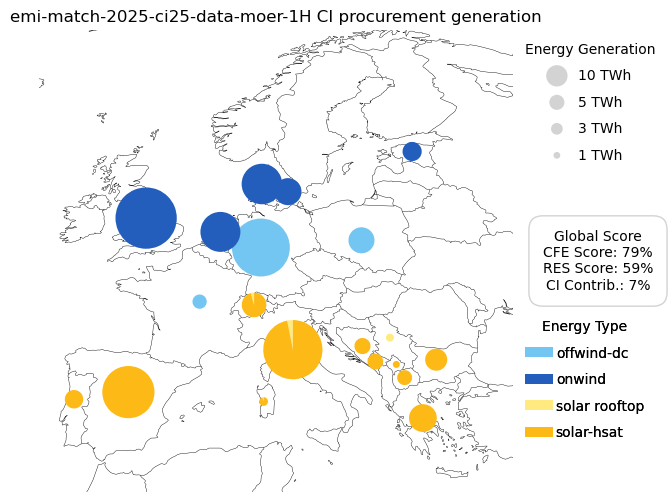

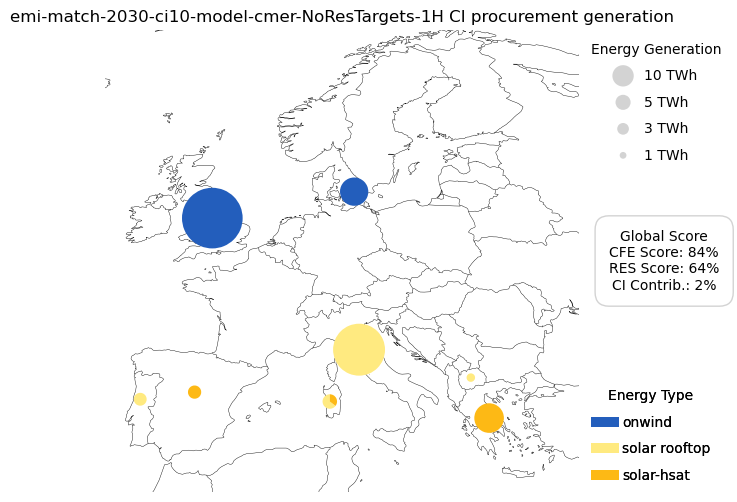

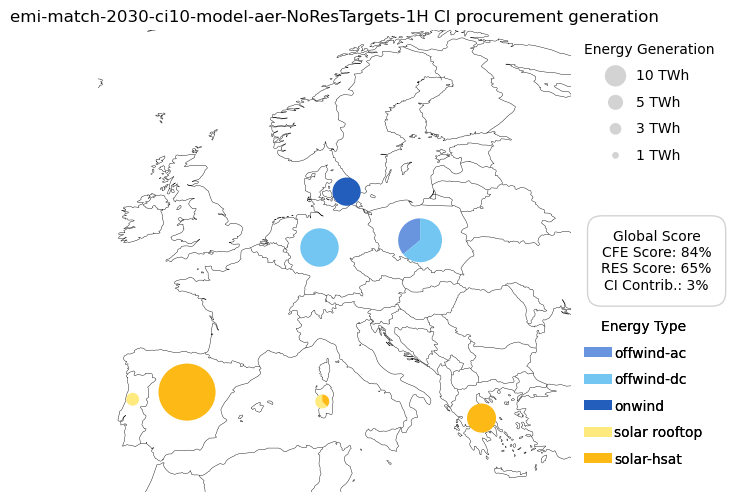

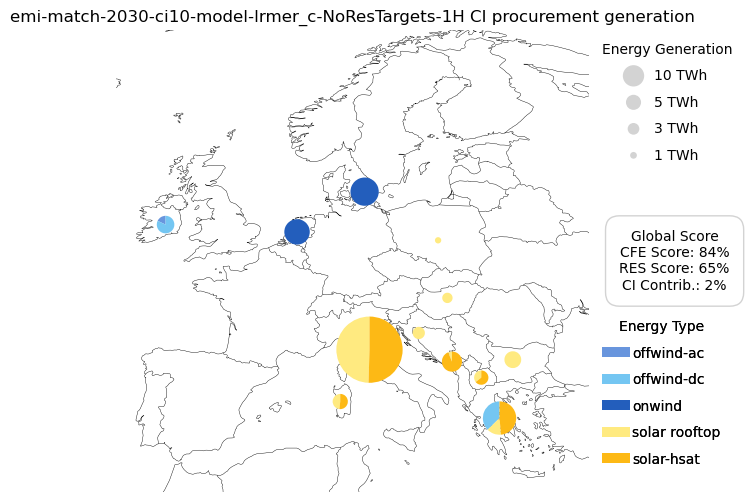

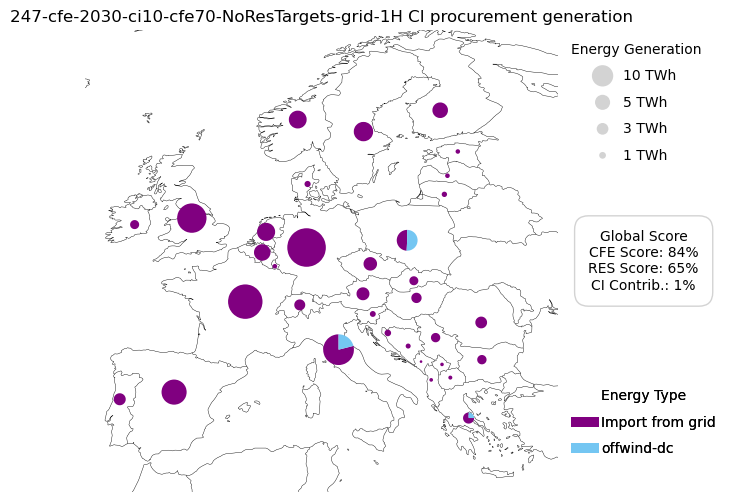

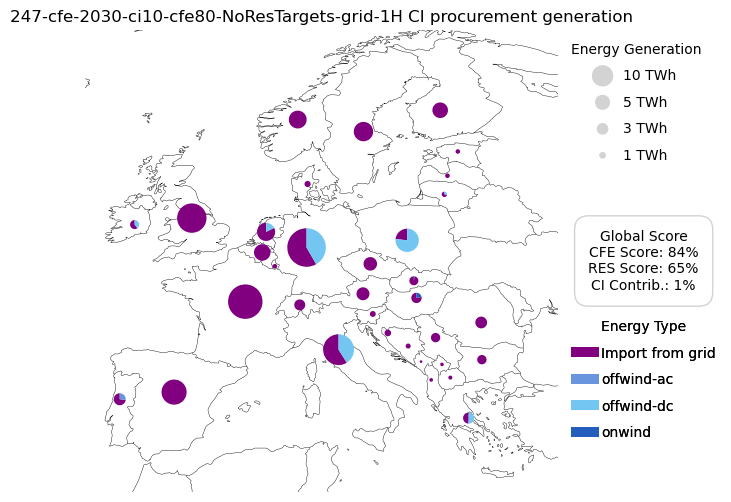

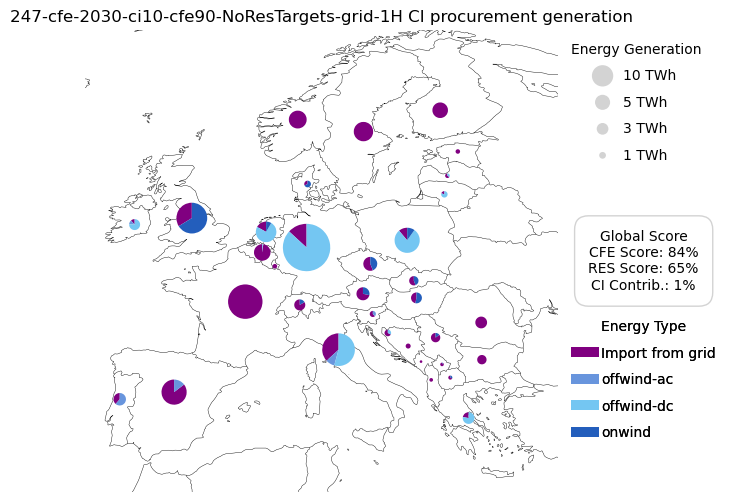

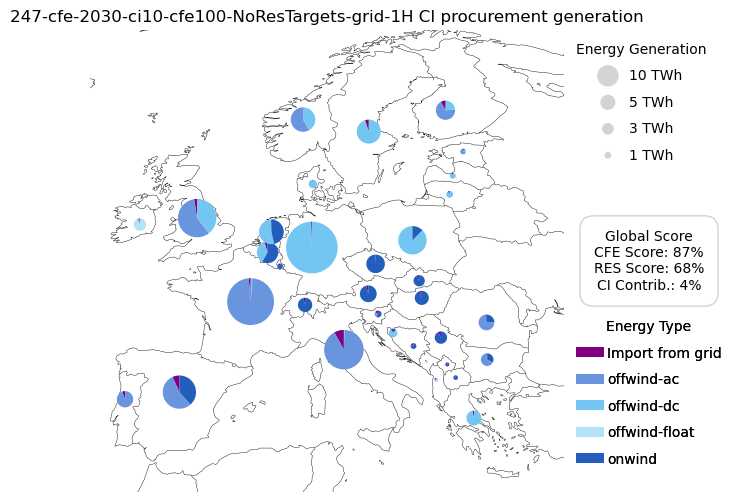

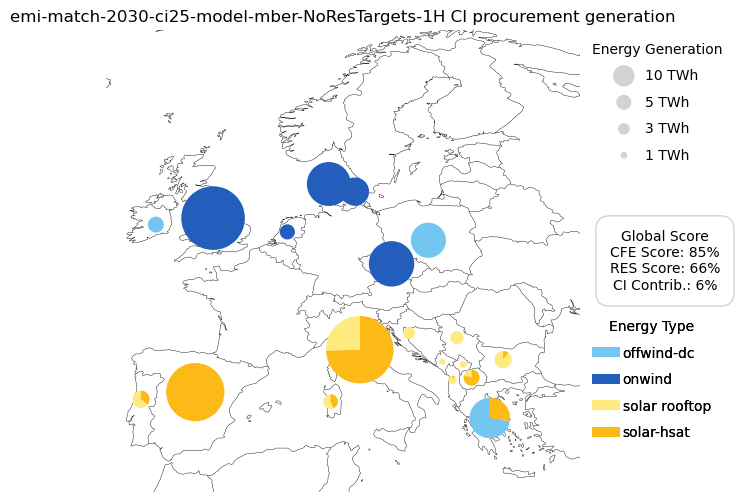

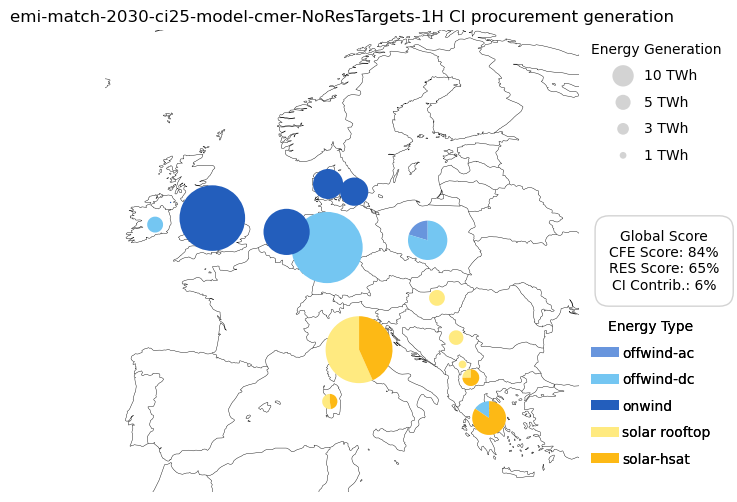

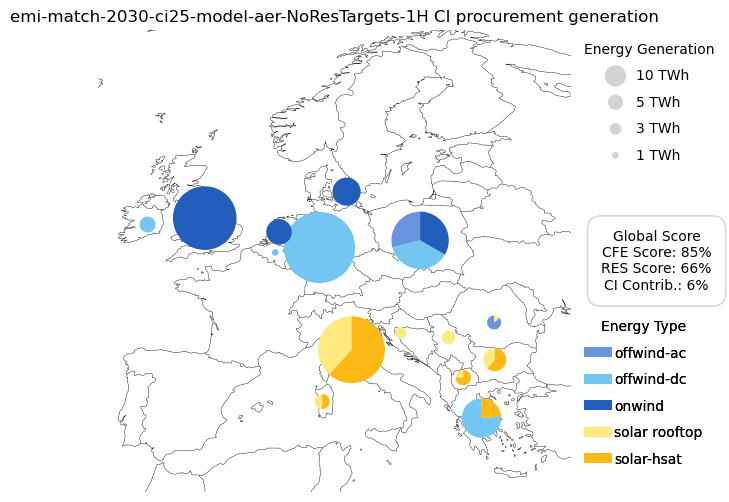

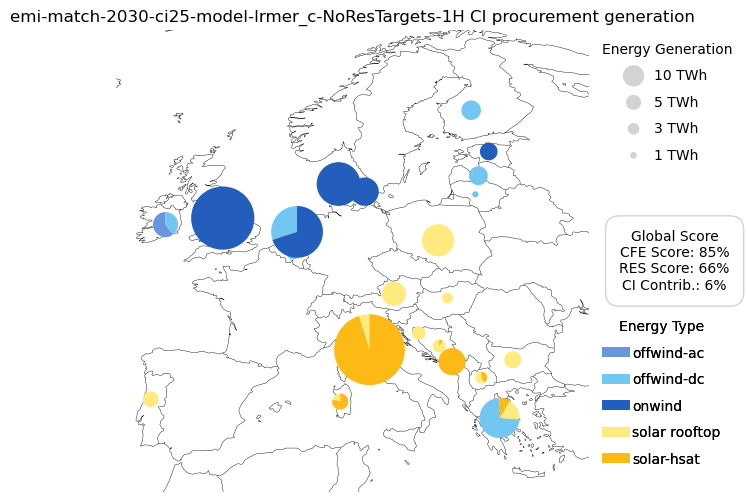

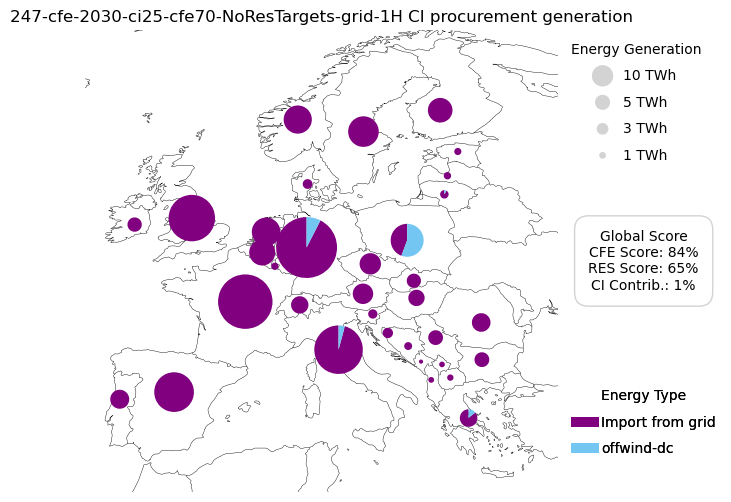

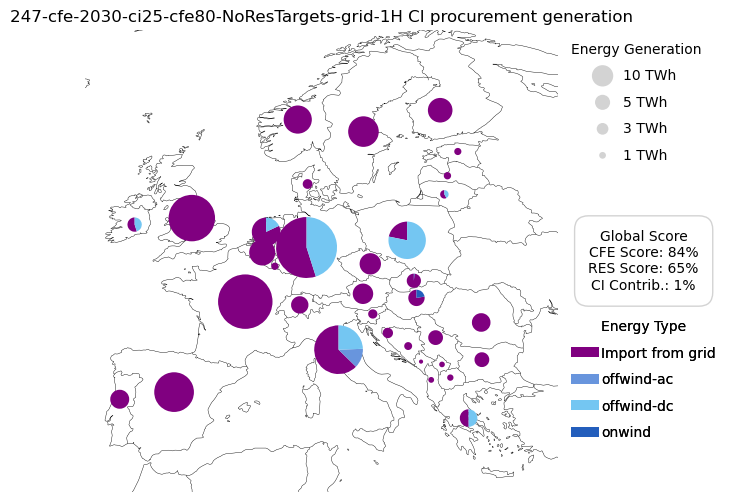

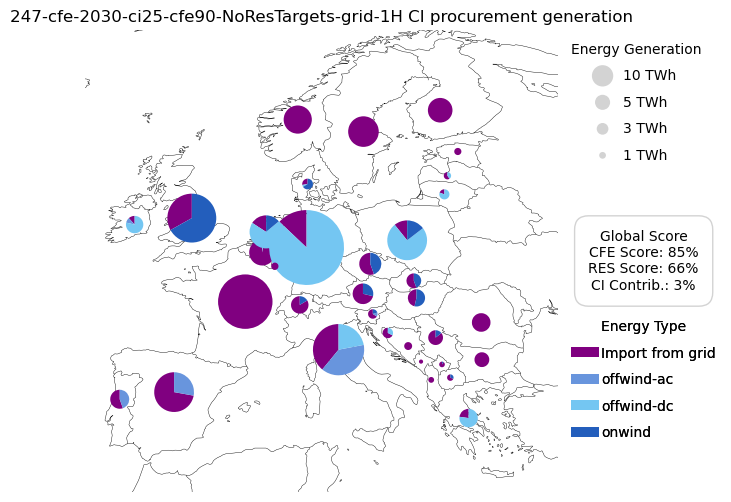

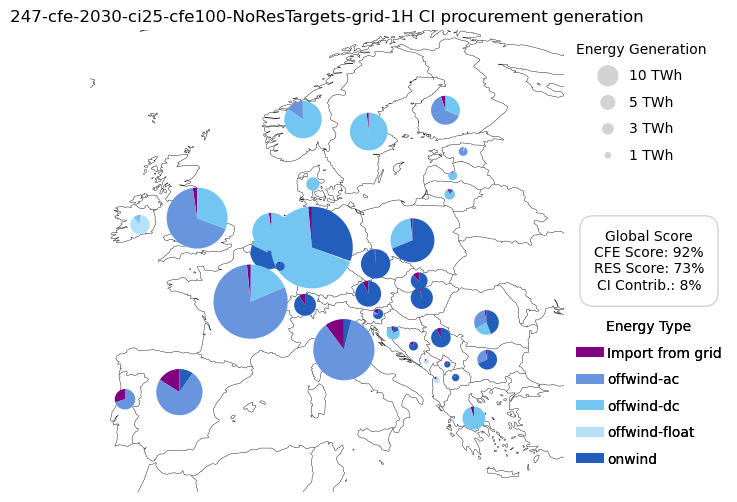

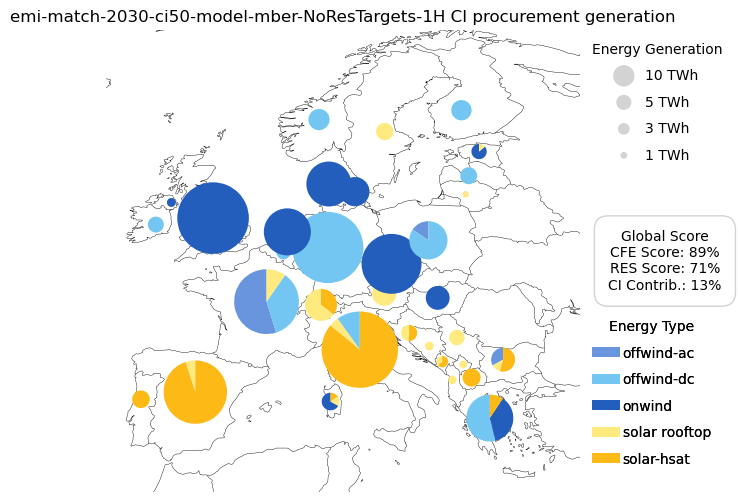

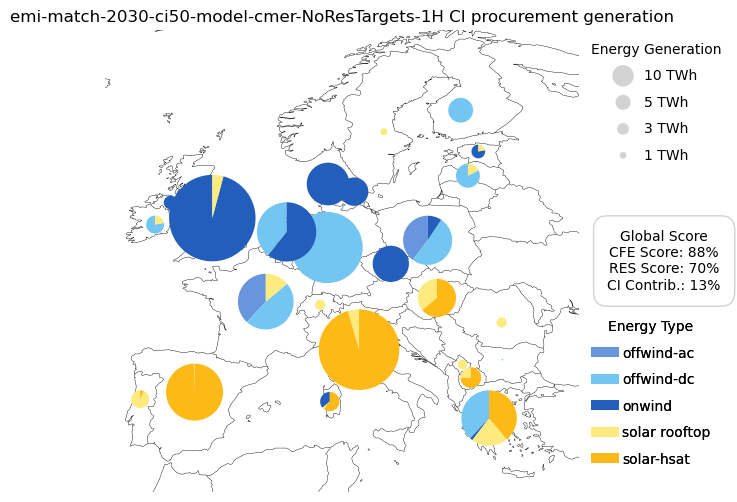

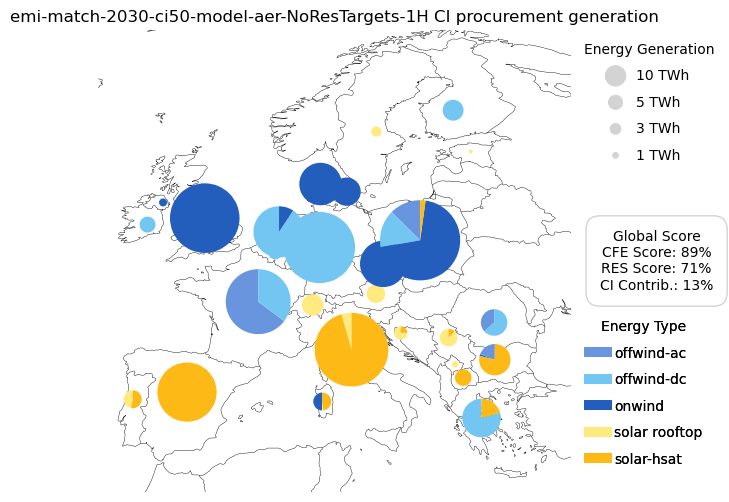

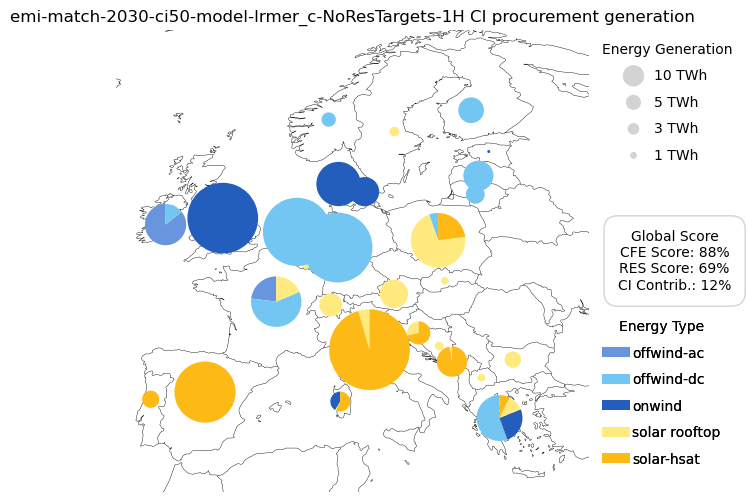

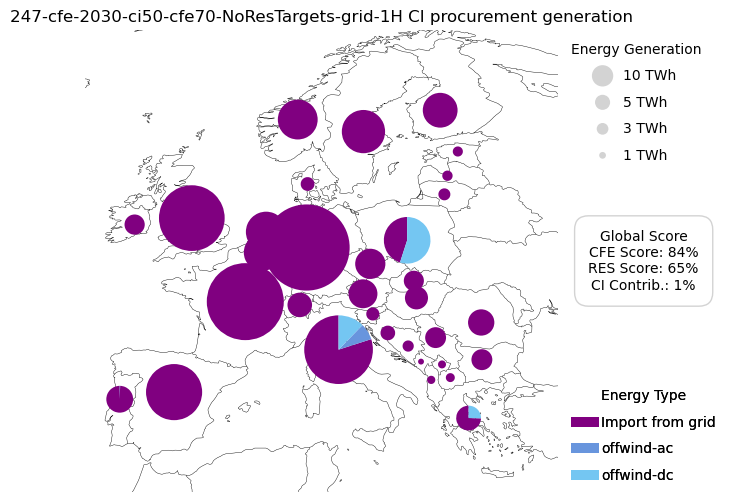

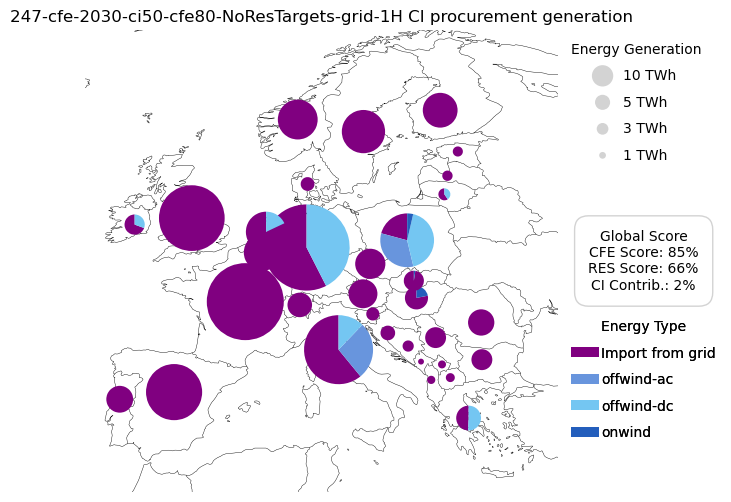

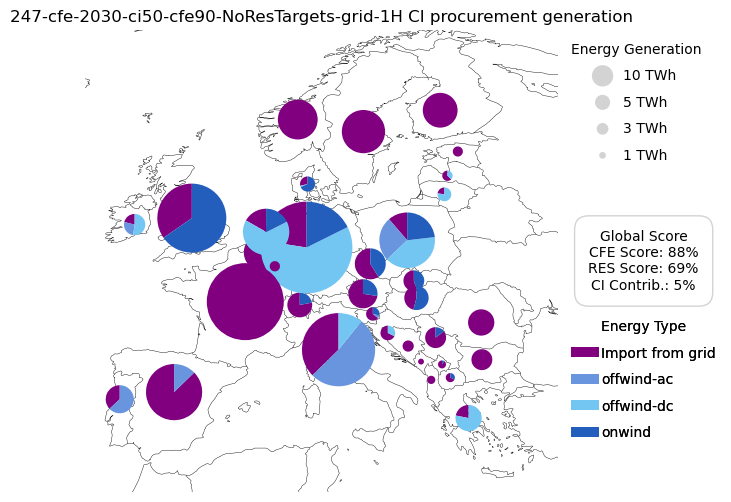

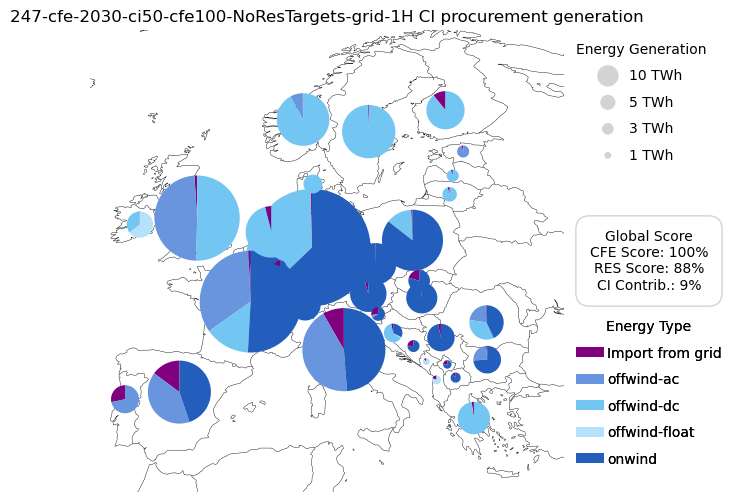

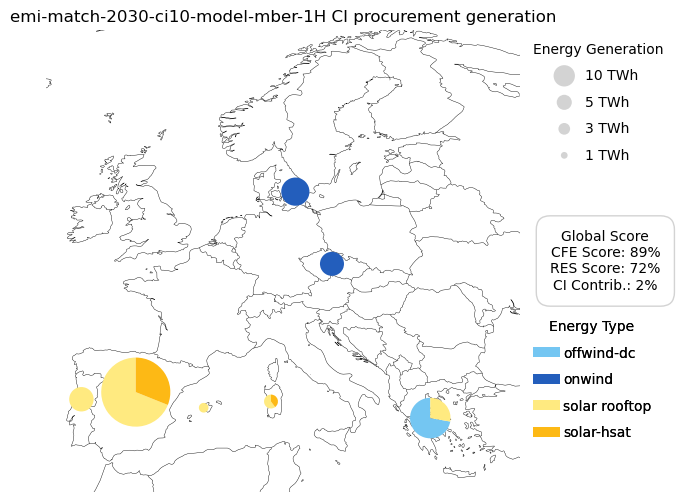

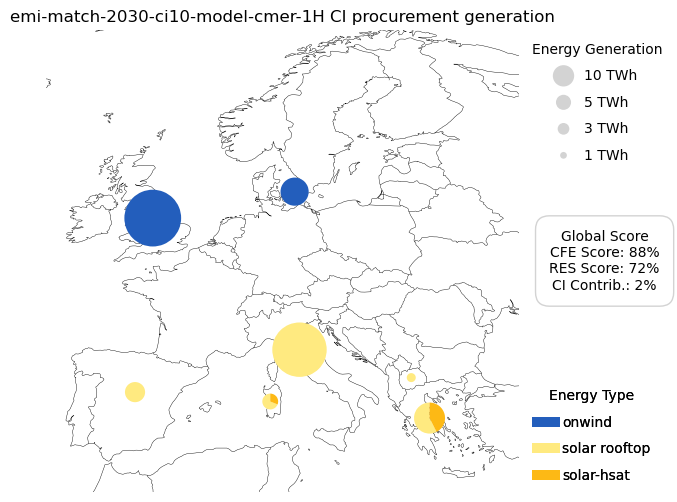

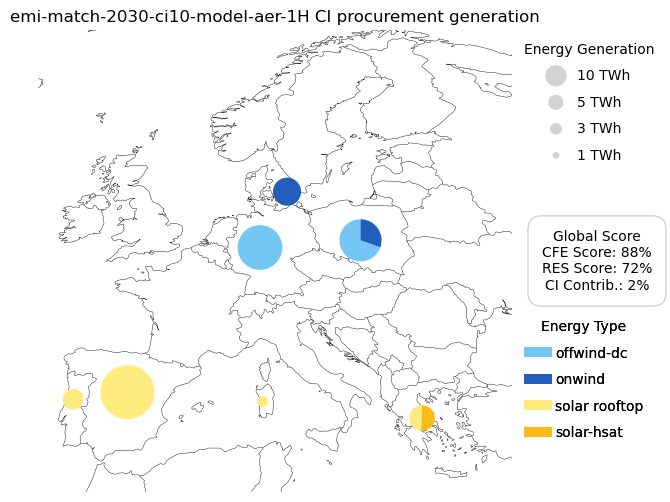

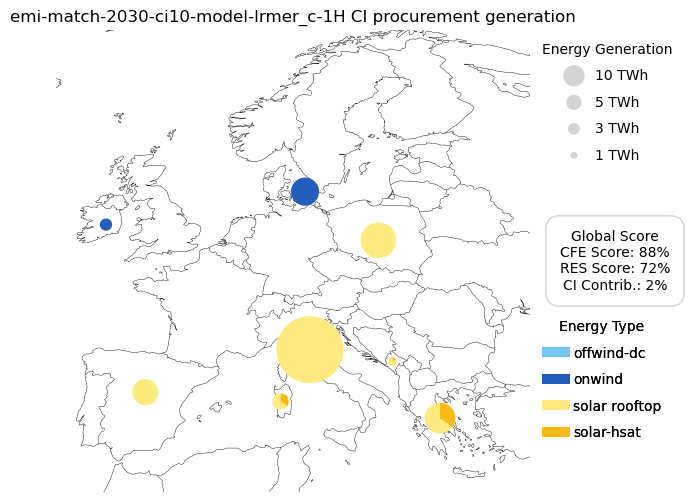

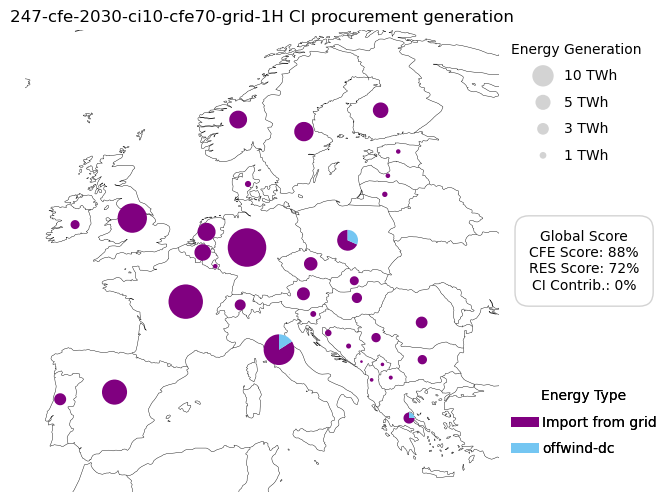

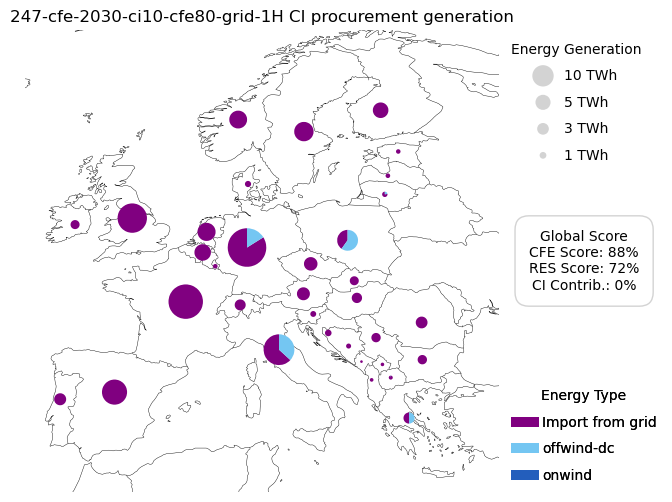

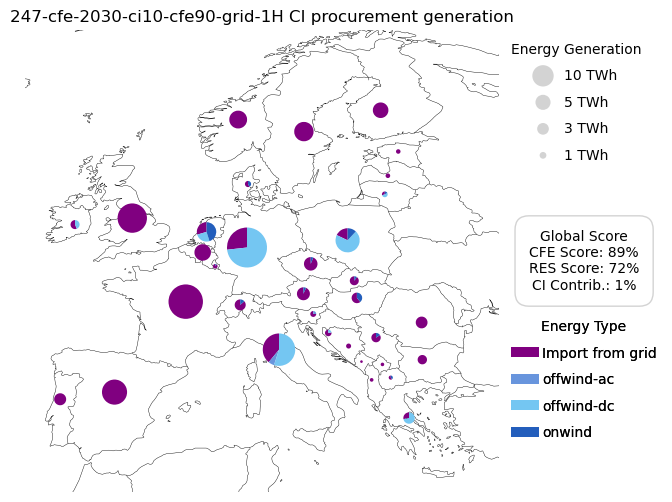

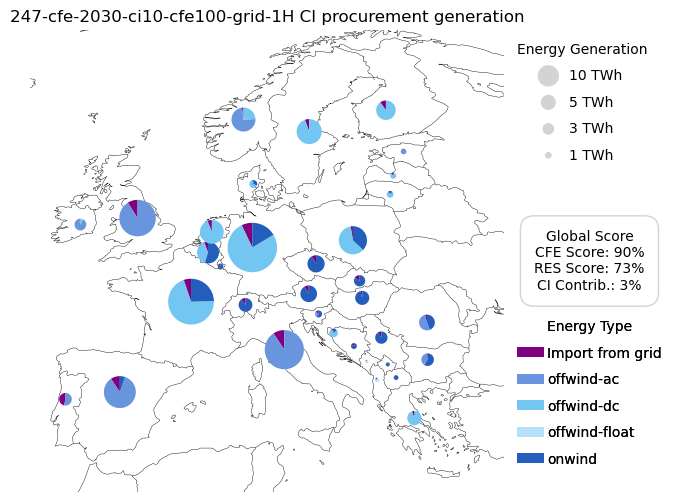

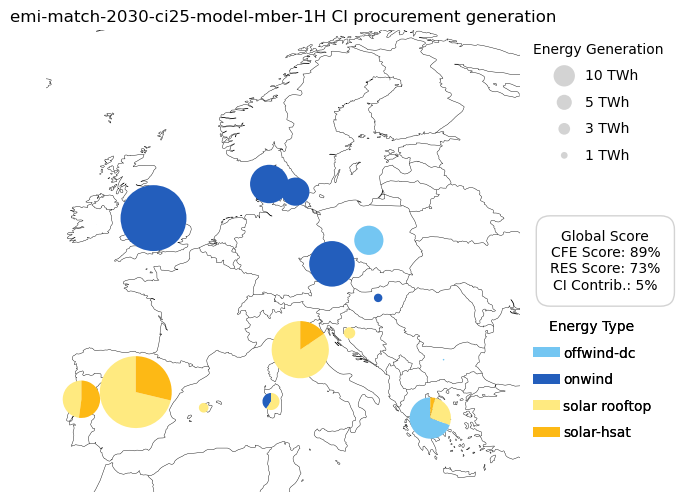

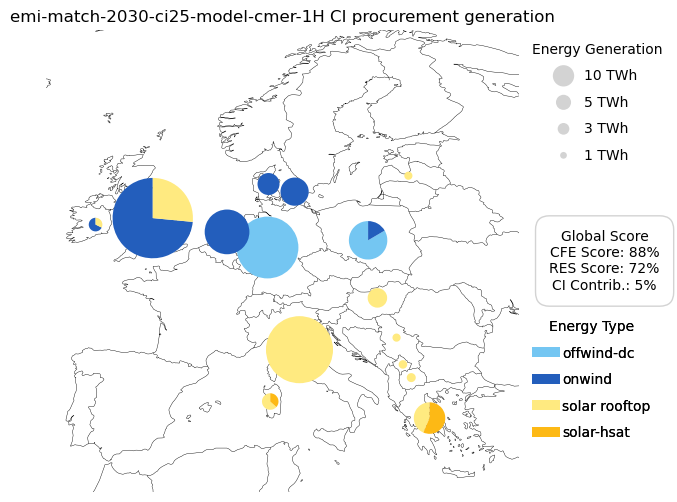

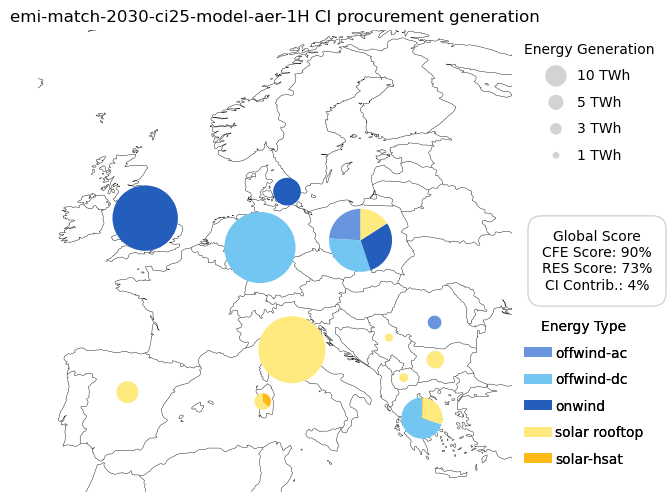

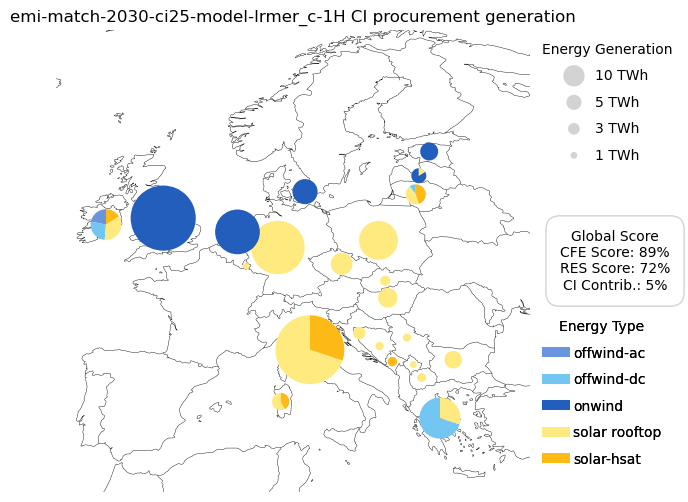

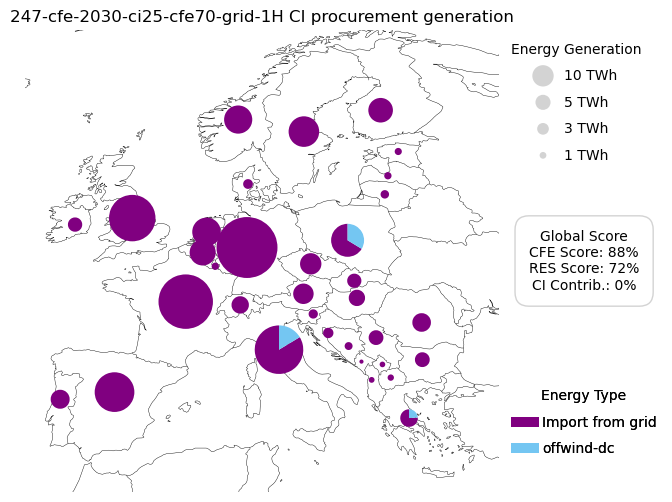

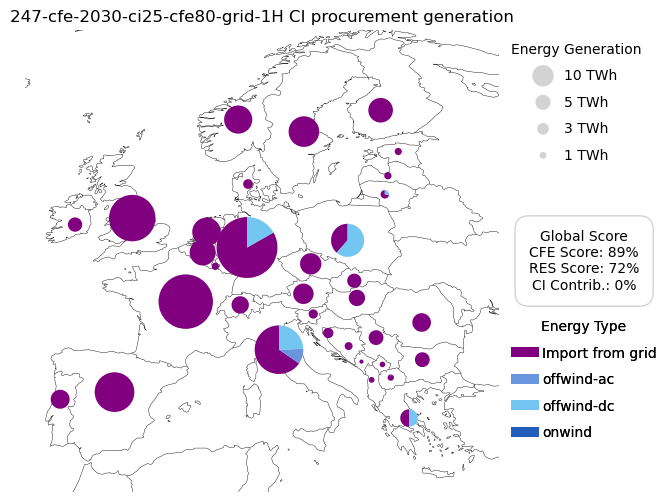

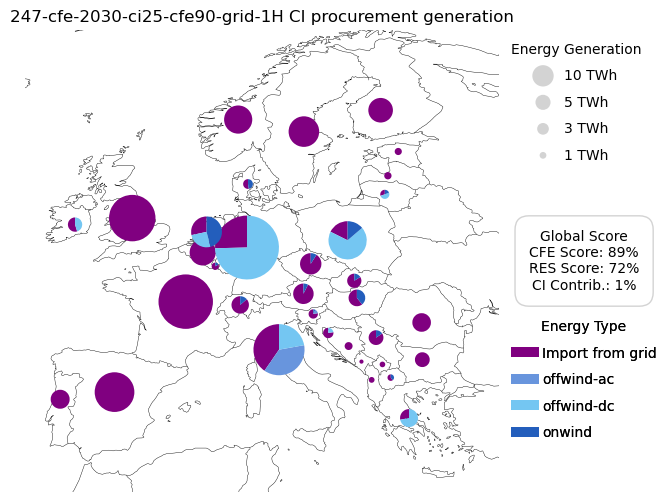

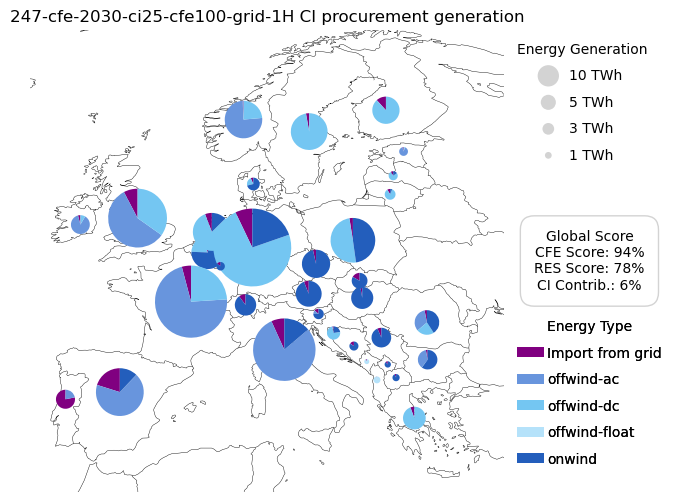

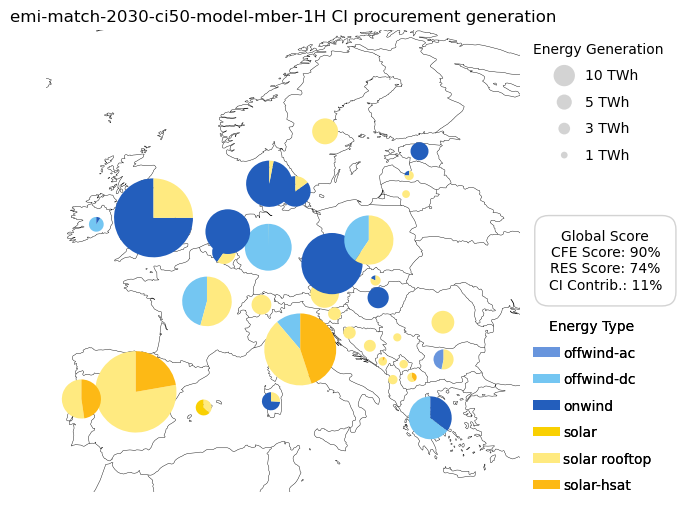

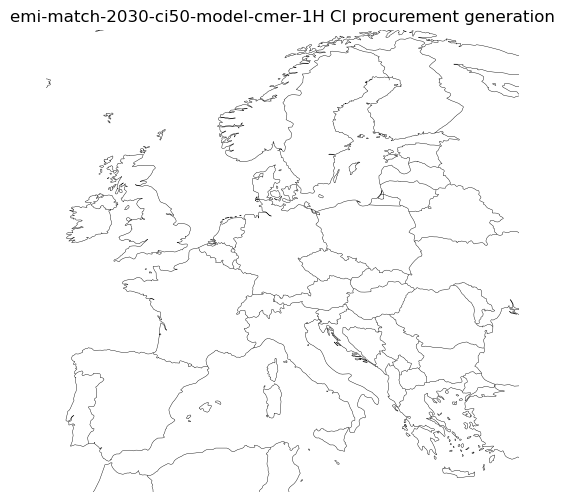

In [15]:
# 1 - Retrieve results
planning_horizon_list = ["2025", "2030"]
time_resolution = "1"
ci_participation = "25"

for planning_horizon in planning_horizon_list:
    print(f"--------Planning Horizon: {planning_horizon}--------")

    scenarios = [f"vol-match-{planning_horizon}-ci{ci_participation}-{time_resolution}H",
                f"vol-match-{planning_horizon}-country-ci{ci_participation}-{time_resolution}H", # only for 2030
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe80-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe70-{time_resolution}H",
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-aer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-mber-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-moer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-data-cmer-{time_resolution}H", # only for 2025
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-{time_resolution}H", # only for 2030
                f"vol-match-{planning_horizon}-NoResTargets-ci{ci_participation}-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-aer-additional-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-mber-additional-{time_resolution}H", # only for 2030
                # f"emi-match-{planning_horizon}-ci{ci_participation}-model-moer-additional-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-cmer-additional-{time_resolution}H", # only for 2030
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-additional-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-additional-{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe100-additional-grid{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe90-additional-grid{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe70-additional{time_resolution}H",
                f"247-cfe-{planning_horizon}-ci{ci_participation}-cfe80-additional{time_resolution}H",
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-lrmer_c-{time_resolution}H", # only for 2030
                f"emi-match-{planning_horizon}-ci{ci_participation}-model-lrmer_c-additional-{time_resolution}H", # only for 2030
                ]
    
    for res in [False, True]:
        for ci_participation in [10, 25, 50]:
            res_tag = "-NoResTargets-" if not res else "-"

            for em_signal in ["mber", "cmer", "aer", "lrmer_c"]:
                em_name = (
                    f"emi-match-2030-ci{ci_participation}-model-{em_signal}{res_tag}1H"
                )
                scenarios.append(em_name)
            for cfe_level in [70, 80, 90, 100]:
                cfe_name = (
                    f"247-cfe-2030-ci{ci_participation}-cfe{cfe_level}{res_tag}grid-1H"
                )
                scenarios.append(cfe_name)
    

    for scenario in scenarios:
        network_path = get_network_path(scenario, path = False)

        if network_path is None: # if the scenario is not found (either the folder or the network in the folder)
            continue

        network = pypsa.Network(network_path)
        print(f"----Scenario: {scenario}----")
        plot_ci_allocation(network, scenario)

INFO:pypsa.network.io:New version 0.35.2 available! (Current: 0.35.0)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


----Scenario: baseline-2030-1H----


/var/folders/2v/5m_lctsx75xbqh8c9400hpfr0000gn/T/ipykernel_13404/3092487821.py:232: UserWarning:

When combining n.plot() with other plots on a geographical axis, ensure n.plot() is called first or the final axis extent is set initially (ax.set_extent(boundaries, crs=crs)) for consistent legend circle sizes.



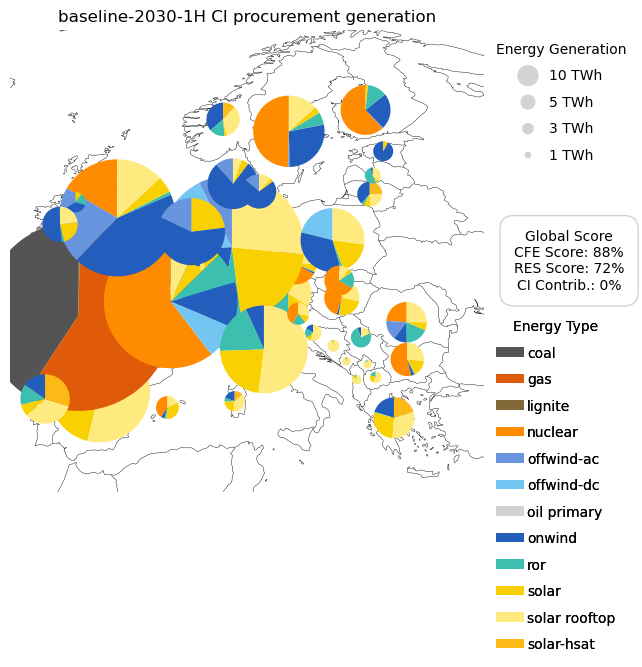

In [14]:
scenarios = ['baseline-2030-1H']

for scenario in scenarios:
    network_path = get_network_path(scenario, path = False)

    if network_path is None: # if the scenario is not found (either the folder or the network in the folder)
        continue

    network = pypsa.Network(network_path)
    print(f"----Scenario: {scenario}----")
    plot_ci_allocation(network, scenario, only_ci=False)